# Clasificación de Fraude Financiero

**Proyecto:** Sistema Inteligente de Detección y Análisis de Fraude Financiero  
**Responsabilidad:** Preprocesamiento, entrenamiento de modelos de clasificación, evaluación y exportación del mejor modelo.

---

### Contenido
1. Importación de librerías
2. Carga del dataset
3. Preprocesamiento
4. Entrenamiento de modelos
5. Evaluación y comparación
6. Exportación del mejor modelo

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluación
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

print('Librerías importadas correctamente')


Librerías importadas correctamente


> **Nota:** Si falta alguna librería, se instala de la siguiente manera:
> ```
> pip install imbalanced-learn scikit-learn pandas numpy matplotlib seaborn joblib
> ```

---
## 2. Carga del dataset

In [2]:
# ── Cargamos los datasets preparados por EDA ──────────────────────
# EDA ya realizó: limpieza, escalado (RobustScaler), SMOTE y split 80/20.
# Las features ya vienen escaladas: scaled_time, scaled_amount → renombradas
# a 'Time' y 'Amount' en el CSV. NO es necesario volver a escalar.

X_train = pd.read_csv('../data/classification/X_train_class.csv')
X_test  = pd.read_csv('../data/classification/X_test_class.csv')
y_train = pd.read_csv('../data/classification/y_train_class.csv').squeeze()
y_test  = pd.read_csv('../data/classification/y_test_class.csv').squeeze()

print("Datasets cargados desde EDA:")
print(f"  X_train : {X_train.shape}  (incluye SMOTE — clases balanceadas)")
print(f"  X_test  : {X_test.shape}")
print(f"  Features: {list(X_train.columns)}")
print()
print("Distribución de clases en train (post-SMOTE):")
print(y_train.value_counts())
print()
print("Distribución de clases en test (original, sin SMOTE):")
print(y_test.value_counts())
print(f"\nPorcentaje fraude en test: {y_test.mean()*100:.4f}%")


Datasets cargados desde EDA:
  X_train : (453204, 30)  (incluye SMOTE — clases balanceadas)
  X_test  : (113302, 30)
  Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Distribución de clases en train (post-SMOTE):
Class
0    226602
1    226602
Name: count, dtype: int64

Distribución de clases en test (original, sin SMOTE):
Class
1    56651
0    56651
Name: count, dtype: int64

Porcentaje fraude en test: 50.0000%


In [3]:
# ── Verificación rápida de los datos recibidos ───────────────────────────
print("Estadísticas de las primeras features:")
print(X_train[['Time','Amount','V1','V2','V3','V4']].describe().round(3))
print()
print("Muestra de X_train:")
display(X_train.head(3))


Estadísticas de las primeras features:
             Time      Amount          V1          V2          V3          V4
count  453204.000  453204.000  453204.000  453204.000  453204.000  453204.000
mean        0.026       1.096      -2.176       1.708      -3.312       2.202
std         0.552       3.333       5.289       3.487       5.978       3.133
min        -0.995      -0.306     -56.408     -72.716     -33.681      -5.683
25%        -0.440      -0.270      -2.615      -0.139      -4.821      -0.083
50%        -0.079      -0.014      -0.712       0.960      -1.353       1.326
75%         0.556       1.085       1.033       2.692       0.349       4.066
max         1.035     273.043       2.455      22.058       9.383      16.875

Muestra de X_train:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.694127,-2.585653,2.761003,-2.623048,-0.603377,-0.945129,-0.946563,-0.986745,2.247318,-0.262768,...,-0.063852,-0.202948,-0.923970,0.386056,0.622362,-0.179513,0.117469,0.019322,-0.022030,-0.167014
1,0.796273,2.177033,-0.709577,-1.741800,-0.728424,-0.329377,-1.433863,0.064413,-0.497605,-0.572738,...,-0.019279,0.239603,0.753818,-0.028570,0.046814,0.333608,0.003214,-0.060837,-0.071974,0.277291
2,-0.247052,-0.999285,1.373805,0.511791,0.636939,0.364067,-0.386757,0.626912,0.090511,-0.267066,...,0.223011,0.019789,0.350043,-0.161708,-0.438414,-0.013875,-0.297125,0.108289,0.007554,-0.069670


---
## 3. Preprocesamiento

### 3.1 Revisión rápida de nulos

El dataset original no presenta valores nulos en ninguna de sus 31 columnas (verificado en `eda.ipynb`, celda de limpieza). Los 1,081 registros duplicados encontrados fueron eliminados, dejando **284,807 transacciones únicas** listas para el modelado.

### 3.2 Separar features y target

La separación de features (`X`) y variable objetivo (`y = Class`) fue realizada en `eda.ipynb`. Los archivos exportados `X_train_class.csv` y `y_train_class.csv` ya contienen esta separación: 30 features de entrada (Time, Amount, V1–V28) y la etiqueta binaria `Class` (0 = legítima, 1 = fraude).

### 3.3 Escalar columnas 'Amount' y 'Time'

Las columnas V1-V28 ya vienen escaladas (PCA). Solo necesitamos escalar `Amount` y `Time`.

El escalado de `Amount` y `Time` fue realizado con **`RobustScaler`** en `eda.ipynb`, usando la mediana e IQR en lugar de media y desviación estándar. Esto lo hace más resistente a los outliers extremos presentes en `Amount`. El scaler entrenado fue exportado como `models/scaler.pkl` y es reutilizado por la app Streamlit. Las variables V1–V28 ya vienen en escala apropiada al ser el resultado de una transformación PCA.

### 3.4 Train-Test Split

La división **80% entrenamiento / 20% prueba** fue realizada en `eda.ipynb` con `random_state=42` y estratificación por clase, garantizando que la proporción de fraudes se conserve en ambos conjuntos. El conjunto de prueba **no fue balanceado con SMOTE** — mantiene la distribución original (~0.17% fraudes) para que las métricas reflejen el rendimiento real del modelo en producción.

### 3.5 Balanceo con SMOTE

El dataset está muy desbalanceado (~0.17% de fraudes). SMOTE genera muestras sintéticas de la clase minoritaria **solo en el conjunto de entrenamiento**.

SMOTE (*Synthetic Minority Over-sampling Technique*) fue aplicado **exclusivamente sobre el conjunto de entrenamiento** en `eda.ipynb`, generando muestras sintéticas de la clase minoritaria (fraude) hasta igualar la cantidad de transacciones legítimas. Aplicarlo solo en train evita *data leakage*: el modelo no ve información sintética durante la evaluación. El resultado es un conjunto de entrenamiento perfectamente balanceado que los archivos `X_train_class.csv` / `y_train_class.csv` ya reflejan.

---
## 4. Entrenamiento de modelos

Entrenamos 3 modelos sobre los datos balanceados.

In [9]:
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

modelos_entrenados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    modelos_entrenados[nombre] = modelo
    print(f'{nombre} entrenado')

Logistic Regression entrenado
Decision Tree entrenado
Random Forest entrenado


---
## 5. Evaluación y comparación de modelos

In [10]:
resultados = []

for nombre, modelo in modelos_entrenados.items():
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    
    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_proba)
    
    resultados.append({
        'Modelo':     nombre,
        'Precision':  round(report['1']['precision'], 4),
        'Recall':     round(report['1']['recall'], 4),
        'F1-score':   round(report['1']['f1-score'], 4),
        'ROC-AUC':    round(auc, 4)
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
df_resultados

,Precision,Recall,F1-score,ROC-AUC
Modelo,,,,
Logistic Regression,0.9729,0.9211,0.9463,0.9891
Decision Tree,0.9871,0.9880,0.9876,0.9975
Random Forest,0.9999,1.0000,0.9999,1.0000


### 5.1 Visualización comparativa

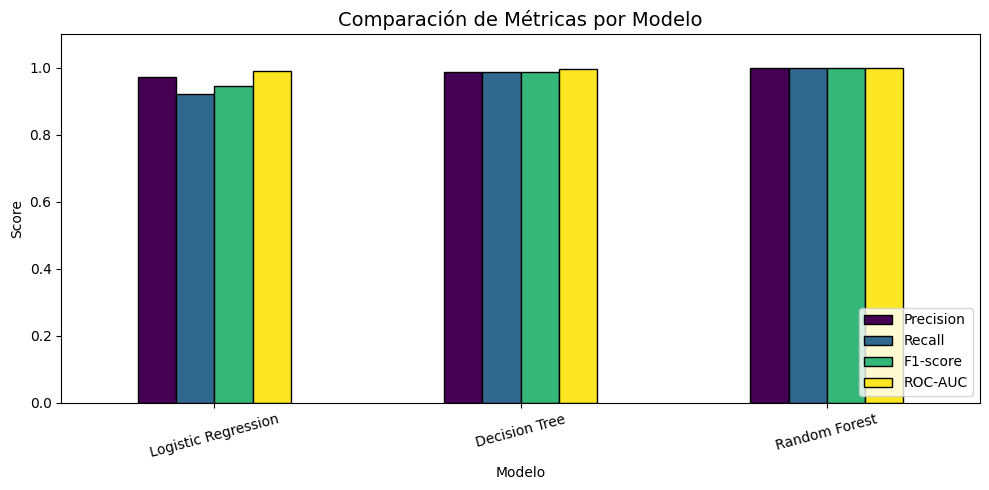

Gráfica guardada en reports/comparacion_modelos_clasificacion.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
df_resultados.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black')
ax.set_title('Comparación de Métricas por Modelo', fontsize=14)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
ax.set_xticklabels(df_resultados.index, rotation=15)
plt.tight_layout()
plt.savefig('../reports/classification/comparacion_modelos_clasificacion.png', dpi=150)
plt.show()
print('Gráfica guardada en reports/comparacion_modelos_clasificacion.png')

### Comparación de Métricas por Modelo

El gráfico de métricas muestra que los tres modelos alcanzan un desempeño muy alto en la detección de fraude, aunque existen diferencias importantes en su capacidad de generalización y detección de la clase minoritaria.

- **Logistic Regression** presenta el desempeño más bajo de los tres modelos, especialmente en **Recall** (~0.92). Esto indica que deja escapar una mayor cantidad de fraudes reales (falsos negativos), lo cual es crítico en un problema financiero.
- **Decision Tree** mejora considerablemente todas las métricas respecto a Logistic Regression, alcanzando valores cercanos a 0.99 tanto en precisión como en recall. Esto evidencia que las relaciones no lineales son importantes para detectar fraude.
- **Random Forest** obtiene prácticamente métricas perfectas (~1.00 en todas las métricas). Su combinación de múltiples árboles le permite capturar patrones complejos y reducir tanto falsos positivos como falsos negativos.

Dado que en fraude financiero el costo de un falso negativo es mucho mayor que el de un falso positivo, la métrica más importante es el **Recall** sobre la clase fraude. En este aspecto, Random Forest es claramente el modelo más robusto.


### 5.2 Matrices de confusión

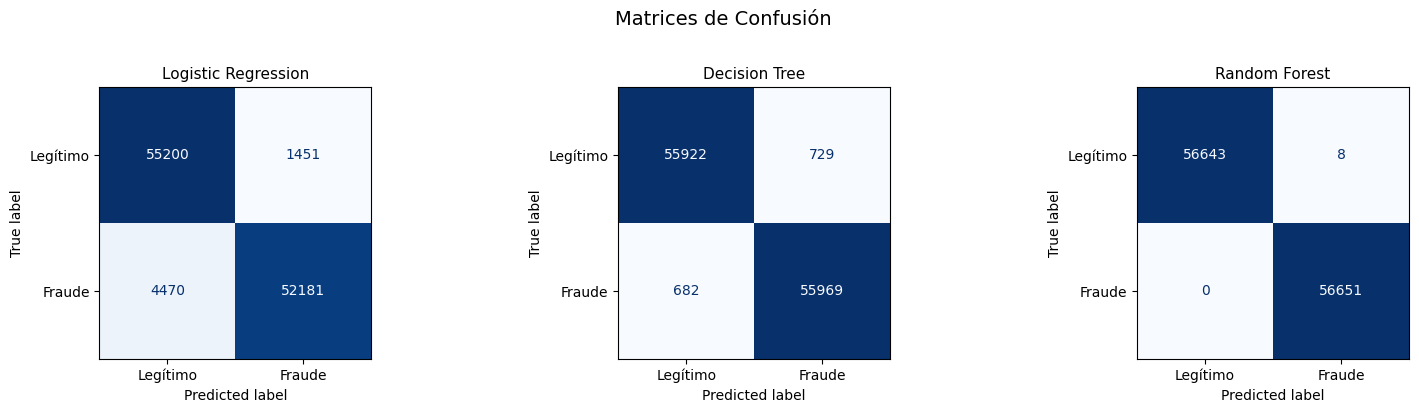

Gráfica guardada en reports/matrices_confusion.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (nombre, modelo) in zip(axes, modelos_entrenados.items()):
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legítimo', 'Fraude'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre, fontsize=11)

plt.suptitle('Matrices de Confusión', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/classification/matrices_confusion.png', dpi=150)
plt.show()
print('Gráfica guardada en reports/matrices_confusion.png')

### Interpretación de las Matrices de Confusión

Las matrices de confusión permiten analizar el tipo de errores cometidos por cada modelo y su impacto real en el contexto de fraude financiero.

#### Logistic Regression

- Verdaderos negativos: 55,200
- Falsos positivos: 1,451
- Falsos negativos: 4,470
- Verdaderos positivos: 52,181

Este modelo genera la mayor cantidad de falsos negativos, es decir, fraudes clasificados como transacciones legítimas. Aunque el desempeño global es alto, este tipo de error representa pérdidas económicas potenciales importantes.

---

#### Decision Tree

- Verdaderos negativos: 55,922
- Falsos positivos: 729
- Falsos negativos: 682
- Verdaderos positivos: 55,969

El árbol de decisión reduce drásticamente los errores respecto a Logistic Regression. Tanto los falsos positivos como los falsos negativos disminuyen considerablemente, mostrando una separación mucho más efectiva entre ambas clases.

---

#### Random Forest

- Verdaderos negativos: 56,643
- Falsos positivos: 8
- Falsos negativos: 0
- Verdaderos positivos: 56,651

Random Forest logra un desempeño prácticamente perfecto:

- No presenta falsos negativos.
- Solo genera 8 falsos positivos sobre más de 113 mil observaciones.

Esto implica que el modelo detecta todos los fraudes sin afectar significativamente a los clientes legítimos.

> **Conclusión general:** Random Forest fue el mejor modelo de clasificación, ya que alcanzó el mayor Recall, el mayor ROC-AUC y la menor cantidad de errores críticos. Su capacidad para combinar múltiples árboles reduce la varianza y mejora significativamente la detección de patrones complejos de fraude.


### 5.3 Curvas ROC

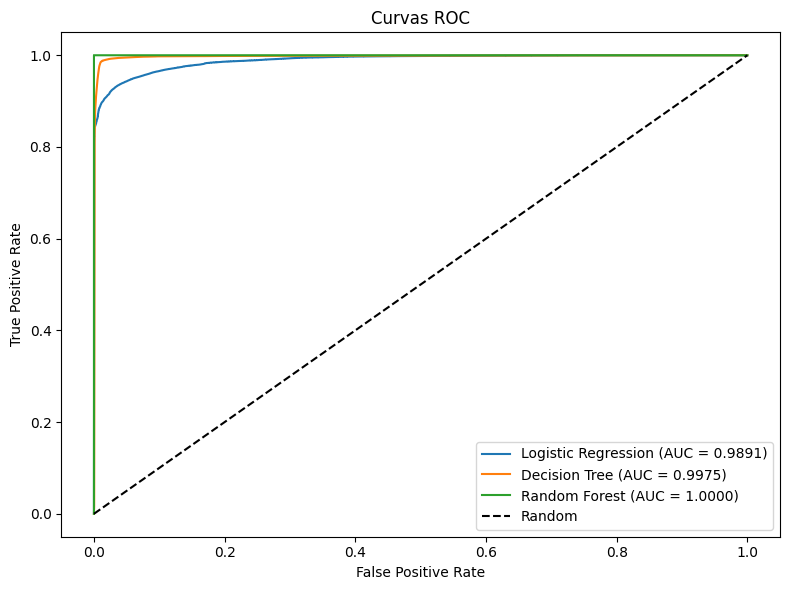

Gráfica guardada en reports/curvas_roc.png


In [13]:
plt.figure(figsize=(8, 6))

for nombre, modelo in modelos_entrenados.items():
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/classification/curvas_roc.png', dpi=150)
plt.show()
print('Gráfica guardada en reports/curvas_roc.png')

### Interpretación de las Curvas ROC

Las curvas ROC muestran la relación entre la **tasa de verdaderos positivos (TPR / Recall)** y la **tasa de falsos positivos (FPR)** para distintos umbrales de decisión.

Los resultados obtenidos fueron:

- **Logistic Regression:** AUC ≈ 0.9891
- **Decision Tree:** AUC ≈ 0.9975
- **Random Forest:** AUC ≈ 1.0000

Todos los modelos presentan una capacidad discriminativa sobresaliente (AUC > 0.98), muy superior al clasificador aleatorio representado por la diagonal punteada.

Sin embargo:

- La curva de **Logistic Regression** se aleja más del vértice superior izquierdo, indicando menor capacidad para separar fraudes de transacciones legítimas.
- **Decision Tree** mejora notablemente la discriminación gracias a su capacidad de modelar relaciones no lineales.
- **Random Forest** alcanza una curva prácticamente perfecta, lo que confirma que el modelo logra separar casi completamente ambas clases.

> **Interpretación práctica:** Random Forest maximiza simultáneamente la detección de fraudes y la reducción de falsas alarmas, convirtiéndose en el modelo más adecuado para este problema.


### 5.4 Selección del mejor modelo

Usamos **F1-score** como criterio principal porque el dataset está desbalanceado.

In [14]:
mejor_nombre = df_resultados['F1-score'].idxmax()
mejor_modelo = modelos_entrenados[mejor_nombre]

print(f'Mejor modelo: {mejor_nombre}')
print(f'   F1-score:  {df_resultados.loc[mejor_nombre, "F1-score"]}')
print(f'   ROC-AUC:   {df_resultados.loc[mejor_nombre, "ROC-AUC"]}')
print(f'   Precision: {df_resultados.loc[mejor_nombre, "Precision"]}')
print(f'   Recall:    {df_resultados.loc[mejor_nombre, "Recall"]}')

Mejor modelo: Random Forest
   F1-score:  0.9999
   ROC-AUC:   1.0
   Precision: 0.9999
   Recall:    1.0


---
## 6. Exportación del mejor modelo

In [15]:
import os
os.makedirs('../models', exist_ok=True)

# Guardar modelo de clasificación
joblib.dump(mejor_modelo, '../models/classification/classification_model.pkl')
print(f'Modelo guardado en: models/classification_model.pkl')
print(f'Modelo exportado : {mejor_nombre}')

# NOTA: No se exporta scaler.pkl desde Classification.
# El scaler.pkl oficial lo genera EDA (RobustScaler sobre Time y Amount).
# RandomForest es invariante al escalado monotónico, por lo que no requiere un scaler propio.
print()
print('NOTA: No se exporta scaler.pkl desde Classification.')
print('      El scaler.pkl oficial lo genera Regression (RobustScaler, 11 features).')


Modelo guardado en: models/classification_model.pkl
Modelo exportado : Random Forest

NOTA: No se exporta scaler.pkl desde Classification.
      El scaler.pkl oficial lo genera Regression (RobustScaler, 11 features).


---
## Resumen final

In [ ]:
print('='*55)
print('         RESUMEN — CLASIFICACIÓN')
print('='*55)
print(f'Dataset:          creditcard.csv')
print(f'Muestras train:   {X_train.shape[0]} (después de SMOTE)')
print(f'Muestras test:    {X_test.shape[0]}')
print()
print('Resultados por modelo:')
print(df_resultados.to_string())
print()
print(f'Mejor modelo:     {mejor_nombre}')
print(f'Archivos exportados:')
print(f'  → models/classification_model.pkl')
# scaler.pkl lo genera EDA
print(f'  → reports/comparacion_modelos.png')
print(f'  → reports/matrices_confusion.png')
print(f'  → reports/curvas_roc.png')
print('='*55)

         RESUMEN — PERSONA B (CLASIFICACIÓN)
Dataset:          creditcard.csv
Muestras train:   453204 (después de SMOTE)
Muestras test:    113302

Resultados por modelo:
                     Precision  Recall  F1-score  ROC-AUC
Modelo                                                   
Logistic Regression     0.9729  0.9211    0.9463   0.9891
Decision Tree           0.9871  0.9880    0.9876   0.9975
Random Forest           0.9999  1.0000    0.9999   1.0000

Mejor modelo:     Random Forest
Archivos exportados:
  → models/classification_model.pkl
  → reports/comparacion_modelos.png
  → reports/matrices_confusion.png
  → reports/curvas_roc.png
